# Image Search

This notebook builds a searchable image gallery and queries it with an image rather than with text. The gallery is the `Oxford 102 Flowers` dataset [1], each image is turned into a feature vector by a pre-trained `CLIP` model [2], and the vectors are indexed in an `HNSW` graph [3] so that the nearest neighbours of a query are found without scanning the gallery.

The pipeline has four steps:

1. **Embed**: every gallery image is read and passed through `ClipEmbedder`, which returns one vector per image.
2. **Index**: the vectors are handed to the search index that `InMemoryImageEmbeddingStore` owns from then on.
3. **Persist**: the store is written to a single `safetensors` file, embedder included, so the gallery never has to be embedded twice.
4. **Query**: an unseen image is embedded with the same embedder and matched against the index.

> [!NOTE]
>
> Note that embedding the whole gallery takes a while. Once the file is on disk, the notebook can be restarted from the loading cell.

## `Hnsw` Search Index

A brute-force search compares the query against every gallery vector, which is exact but linear in the size of the gallery. `HNSW` instead builds a multi-layer proximity graph over the vectors and walks it greedily, which reaches the neighbourhood of the query in far fewer comparisons. The trade is recall: the answer is approximate, and how approximate is controlled by the parameters set below.

Further reading: [`Image Store`](https://mechacritter.github.io/Python-Visual-Similarity/image_similarity_retrieval/image_store/image_store.html) and [`External Indexes`](https://mechacritter.github.io/Python-Visual-Similarity/image_similarity_retrieval/external_search_index/external_search_index.html).

# Import libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from pyvisim.datasets import OxfordFlowerDataset
from pyvisim.image_store import InMemoryImageEmbeddingStore
from pyvisim.neural_networks import ClipEmbedder

/home/critter_cool_laptop/workspace/Python-Visual-Similarity/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Build the image store

`InMemoryImageEmbeddingStore` reads every path in `image_paths`, embeds it with `embedder`, and hands the resulting matrix to the search index.

The gallery is the training split of `Oxford 102 Flowers` [1], which holds 6149 images.

Arguments:

- `embedder`: any object exposing an `embed` method. `ClipEmbedder` is used here, but the `VLAD`, `Fisher Vector`, `Siamese` and `Triplet` embedders fit here just as well.
- `search_index`: `"hnsw"` builds the graph, `None` falls back to an exact brute-force scan. An `ExternalSearchIndex` can be passed instead to search through a `FAISS` index [5].
- `index_params`: forwarded to the index constructor. `graph_degree` is the number of bidirectional links created per node of the graph, `build_candidates` the size of the candidate list kept while building it. Both raise recall, `graph_degree` at the cost of memory and `build_candidates` at the cost of build time.

The metric space defaults to `"cosine"`, which stores the vectors L2-normalised and scores them by `1 - cosine_similarity`.

In [3]:
train_dataset = OxfordFlowerDataset()
train_image_paths = train_dataset.image_paths

embedder = ClipEmbedder()

image_store = InMemoryImageEmbeddingStore(
    image_paths=train_image_paths,
    embedder=embedder,
    search_index="hnsw",
    index_params={"graph_degree": 16, "build_candidates": 200},
)
image_store.save_to_disk("flower_image_store")

PosixPath('flower_image_store.safetensors')

# Load the store back from disk

The saved file carries the embedder as well, so the store is rebuilt without touching the original images and without downloading the `CLIP` weights again. The index is rebuilt from the saved embeddings, using the parameters it was saved with.

This is the entry point for a fresh session. Run the import cell, then this one, and skip the embedding cell above entirely.

One caveat applies to external indexes only. A `FAISS` index cannot be written into the file, so a rebuilt one has to be handed back as `search_index=...`. Without it the store falls back to an exact brute-force scan over the saved embeddings and warns about the fallback.

In [4]:
image_store = InMemoryImageEmbeddingStore.load_from_disk(
    "flower_image_store.safetensors"
)

# Helper to display images>

In [5]:
def _gallery_labels_by_path():
    dataset = OxfordFlowerDataset()
    return dict(zip(dataset.image_paths, dataset.labels, strict=True))


#: Class id of every gallery image, keyed by its path.
GALLERY_LABELS_BY_PATH = _gallery_labels_by_path()


def _as_rgb_array(image_array_or_path):
    if isinstance(image_array_or_path, np.ndarray):
        return image_array_or_path
    with Image.open(image_array_or_path) as image:
        return np.asarray(image.convert("RGB"))


def visualize_image(image_array_or_path, title=None):
    plt.figure(figsize=(4, 4))
    plt.imshow(_as_rgb_array(image_array_or_path))
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()


def visualize_candidate(candidate):
    label = GALLERY_LABELS_BY_PATH[candidate.path]
    visualize_image(
        candidate.path, title=f"label {label}, score = {candidate.score:.4f}"
    )

# The query image

The query is drawn from the test split, so it was never embedded into the gallery and the search has to generalise to an unseen image. Its own class label is shown above it, and it is the label every retrieved image is measured against further down.

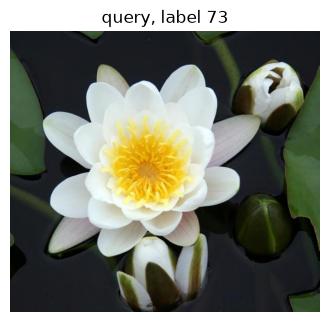

In [6]:
test_dataset = OxfordFlowerDataset(purpose="test")
image1, label1, _ = test_dataset[172]
visualize_image(image1, title=f"query, label {label1}")

# Retrieve the nearest neighbours

`retrieve_top_k_similar` embeds the query with the store's own embedder, walks the index, and maps the returned row ids back to gallery paths.

It takes a batch as readily as a single image and always returns one ranked list per query, which is why the first list is unpacked with `[0]`. Batching is worth using whenever there is more than one query, because the index answers a single `(M, D)` matrix far faster than it answers `M` separate queries.

Each result is a `Candidate`, a named tuple of `path` and `score`, ordered best first. In cosine space the score is `1 - cosine_similarity`, so **lower means more similar** and a near-duplicate of the query scores close to `0.0`.

Query time is bounded by `search_candidates`, the width of the graph walk, which defaults to `50`. Asking for more than `search_candidates` neighbours raises it to `k` automatically.

In [7]:
candidates = image_store.retrieve_top_k_similar(image1, k=5)[0]

# Inspect the results

The top matches should carry the query's own class label. `HNSW` is approximate, so a graph built for speed can miss a true neighbour. If the results look poor, rebuild with a larger `graph_degree` or `build_candidates`, or raise `search_candidates` at query time. Building the store with `search_index=None` gives the exact ranking to compare against, at the cost of scanning the whole gallery on every query.

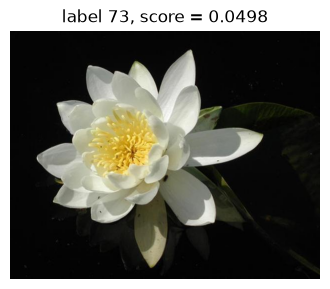

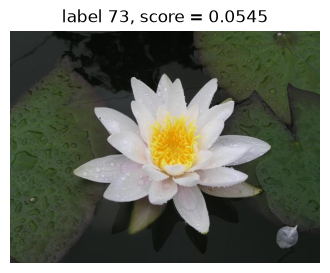

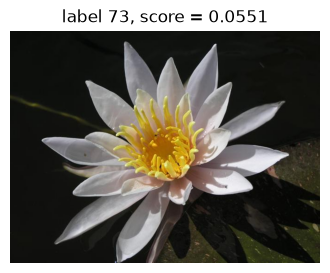

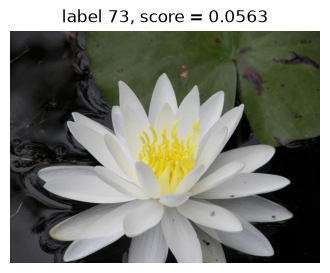

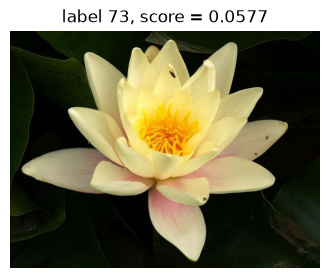

In [8]:
for candidate in candidates:
    visualize_candidate(candidate)

# Refine the query with alpha query expansion

A query is a single point, and a single point can sit off to the side of the group it belongs to. Alpha query expansion (aQE) [7] moves it back towards the middle of that group before the ranking is decided.

The store searches once, reads the embeddings of the `expansion_neighbours` best matches back off the index, and replaces the query by the L2-normalised weighted average of itself and those matches. Each match is weighted by its cosine similarity to the query raised to `expansion_alpha`, so a close match pulls harder than a distant one, and a match whose similarity is not positive does not pull at all. The final search then runs with the refined query.

Arguments:

- `query_expansion`: turns the refinement on. It is off by default, because it costs one extra index search per query plus the decoding of `expansion_neighbours` gallery vectors.
- `expansion_alpha`: exponent of the similarity weights. `0` weights every match with a positive similarity alike, which is the classic average query expansion.
- `expansion_neighbours`: how many of the top-ranked gallery images are averaged into the query.

The scores below are still the store's own distances, so lower still means more similar, but they are measured from the refined query rather than from the one that was embedded and are not comparable to the scores above.

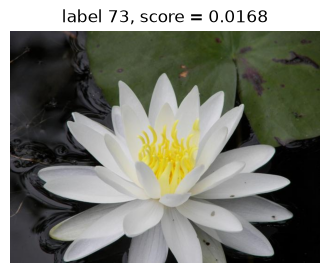

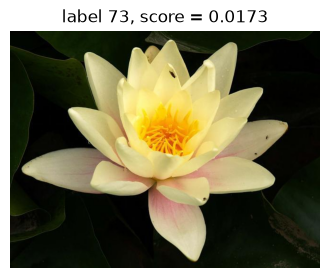

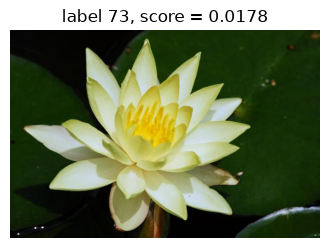

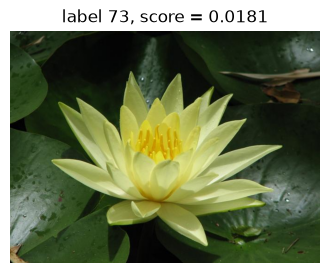

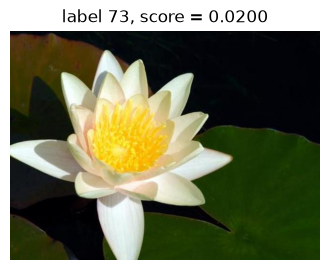

In [9]:
expanded_candidates = image_store.retrieve_top_k_similar(
    image1,
    k=5,
    query_expansion=True,
    expansion_alpha=3.0,
    expansion_neighbours=50,
)[0]

for expanded_candidate in expanded_candidates:
    visualize_candidate(expanded_candidate)

# Re-rank the candidates with k-reciprocal encoding

Query expansion changes the query. Re-ranking leaves the query untouched and re-orders a pool of candidates that has already been retrieved.

`KReciprocalReranker` [8] asks of every candidate whether the query lies among its own nearest neighbours, not only whether it lies among the query's. That relation is far stricter than plain proximity: a false match can sit close to the query while the query sits nowhere near the false match's own neighbours. The query and every candidate are encoded into a k-reciprocal feature, a vector that holds a weight for each of their k-reciprocal neighbours and zero elsewhere, and the Jaccard distance between two such features says how much the two neighbourhoods agree.

The neighbourhoods are built among the candidates themselves, so a pool no larger than the answer leaves them nothing to say. A pool of `100` is retrieved below and the best five are kept.

Arguments:

- `k1`: size of the neighbourhoods the k-reciprocal sets are built from. The pool should hold at least this many candidates.
- `k2`: size of the neighbourhood the local query expansion averages the features over. `1` turns that step off.
- `lambda_value`: weight of the original distance in the final one, from `0` (Jaccard distance only) to `1` (original ranking kept).
- `top_k`: how many of the re-ranked candidates `rerank` returns.

The scores are the final distances of the re-ranking rather than the store's. They lie in `[0, 1]`, and lower again means more similar.

Further reading: [`Re-ranking`](https://mechacritter.github.io/Python-Visual-Similarity/image_similarity_retrieval/reranking/reranking.html).

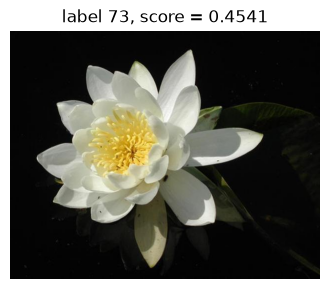

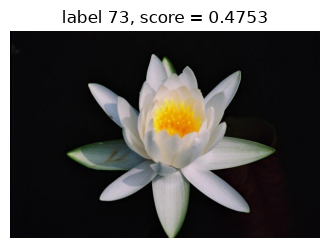

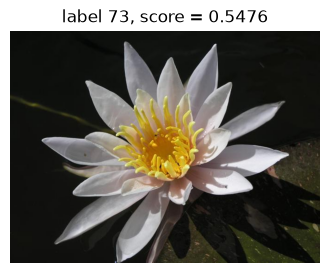

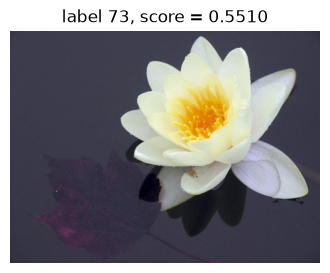

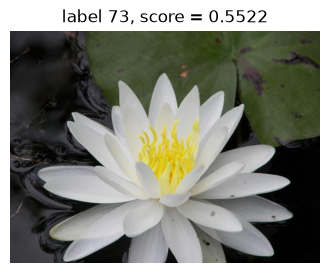

In [10]:
from pyvisim.image_store import KReciprocalReranker

reranker = KReciprocalReranker(image_store, k1=20, k2=6, lambda_value=0.3)

candidate_pool = image_store.retrieve_top_k_similar(image1, k=100)[0]
reranked_candidates = reranker.rerank(candidate_pool, top_k=5)

for reranked_candidate in reranked_candidates:
    visualize_candidate(reranked_candidate)

# Search through a `FAISS` index

`ExternalSearchIndex` lets the store search through an index built by another library, so an algorithm this package does not ship can still be used over the same gallery. The example below rebuilds the `HNSW` graph with `FAISS` [5] and hands it over.

The graph is built over `image_store.embeddings`, the matrix the store's own index holds, so the gallery is never embedded a second time.

Two things are the caller's job here rather than the store's:

- **The metric.** `METRIC_INNER_PRODUCT` ranks by cosine similarity only if the vectors are L2-normalised. They already are, because the store was built in the default `"cosine"` space, and the queries arrive normalised too, because `ClipEmbedder` normalises what it returns.
- **The parameters.** `index_params` is not forwarded to an external index. `m` is a constructor argument of `IndexHNSWFlat`, while `efConstruction` and `efSearch` are set on the graph itself.

`from_faiss_index` reads the gallery vectors back off the index, which `IndexHNSWFlat` can do because it keeps them uncompressed. A quantized index cannot, and needs them passed explicitly as the second argument.

In [11]:
import faiss

from pyvisim.image_store import ExternalSearchIndex

images = [np.array(Image.open(path)) for path in image_store.paths]
gallery_vectors = embedder.embed(images)

faiss_index = faiss.IndexHNSWFlat(
    gallery_vectors.shape[1], 16, faiss.METRIC_INNER_PRODUCT
)
faiss_index.hnsw.efConstruction = 200
faiss_index.add(gallery_vectors)
faiss_index.hnsw.efSearch = 50

faiss_store = InMemoryImageEmbeddingStore(
    image_paths=image_store.paths,
    embedder=embedder,
    search_index=ExternalSearchIndex.from_faiss_index(faiss_index, name="faiss-hnsw"),
)
faiss_store

InMemoryImageEmbeddingStore(num_images=6149, dim=512, index_name='faiss-hnsw', space='cosine')

# Compare the two rankings

The two indexes report their scores in opposite units. `FAISS` was asked for inner products, so its score is a cosine similarity and **higher means more similar**. The built-in index returns the `1 - cosine_similarity` distance of its `"cosine"` space, where lower means more similar. On L2-normalised vectors these are the same quantity read from opposite ends, so `1 - score` converts either one into the other exactly.

**A conversion is therefore applied below.** The `FAISS` similarity is turned into a cosine distance with `1 - faiss_candidate.score` before it is printed, so both columns speak the same units and can be read against each other directly. Neither store rescales anything of its own accord. The conversion is done here in the cell, and what the index itself returned is still `faiss_candidate.score`.

Both graphs are approximate and are built by different code, so the two rankings are free to disagree on a borderline neighbour. On this query they do not.

In [12]:
faiss_candidates = faiss_store.retrieve_top_k_similar(image1, k=5)[0]

for faiss_candidate, hnsw_candidate in zip(faiss_candidates, candidates, strict=True):
    agreement = "same" if faiss_candidate.path == hnsw_candidate.path else "differs"
    faiss_distance = 1.0 - faiss_candidate.score
    print(
        f"{agreement:>7}  faiss={faiss_distance:.4f}  "
        f"hnsw={hnsw_candidate.score:.4f}  {faiss_candidate.path}"
    )

   same  faiss=0.0498  hnsw=0.0498  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00345.jpg
   same  faiss=0.0545  hnsw=0.0545  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00270.jpg
   same  faiss=0.0551  hnsw=0.0551  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00288.jpg
   same  faiss=0.0563  hnsw=0.0563  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00415.jpg
   same  faiss=0.0577  hnsw=0.0577  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00371.jpg


# Persist a store built on an external index

`save_to_disk` writes the embeddings, the paths and the embedder, but not the `FAISS` index itself, which this library cannot serialise. Loading therefore takes a rebuilt index back as `search_index=...`, and its name is checked against the saved one, so a mismatch is reported. Left out, the store falls back to an exact brute-force scan over the saved embeddings and warns about it.

A quantized index needs `vectors=...` passed to `save_to_disk` as well, because what it reconstructs is an approximation of the embeddings rather than the embeddings themselves.

Note that the file written below is a second full copy of the gallery, roughly the size of the one written further up.

In [13]:
faiss_store.save_to_disk("flower_faiss_store")

restored_store = InMemoryImageEmbeddingStore.load_from_disk(
    "flower_faiss_store.safetensors",
    search_index=ExternalSearchIndex.from_faiss_index(faiss_index, name="faiss-hnsw"),
)
restored_candidates = restored_store.retrieve_top_k_similar(image1, k=5)[0]

for restored_candidate in restored_candidates:
    print(f"{restored_candidate.score:.4f}  {restored_candidate.path}")

0.9502  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00345.jpg
0.9455  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00270.jpg
0.9449  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00288.jpg
0.9437  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00415.jpg
0.9423  /home/critter_cool_laptop/.cache/pyvisim/oxford_flower_dataset/images/jpg/image_00371.jpg


# Visualise the results

It can be observed that the results are identical to the ones returned by the built-in index, since the same `hnsw` parameters are used. 

The scores in the titles are the ones `FAISS` itself returned rather than the distances converted further up, so here **higher means more similar**. The labels are read the same way as everywhere else.

Now, you can plug in any `FAISS` index you like for the search.

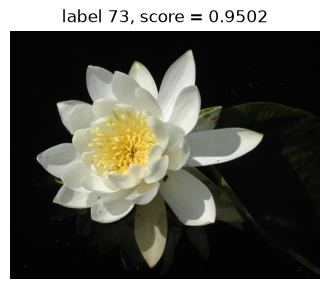

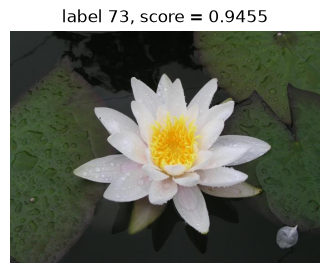

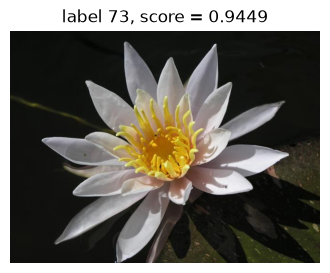

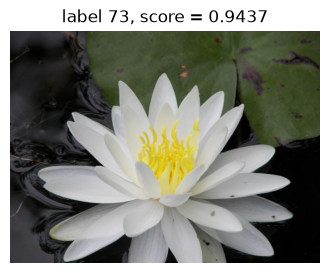

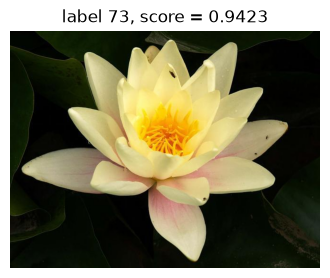

In [14]:
for faiss_candidate in faiss_candidates:
    visualize_candidate(faiss_candidate)

# References

[1] Nilsback, M.-E., & Zisserman, A. (2008). Automated Flower Classification
over a Large Number of Classes. In Proceedings of the Sixth Indian Conference
on Computer Vision, Graphics and Image Processing (ICVGIP), 722-729.
https://www.robots.ox.ac.uk/~vgg/data/flowers/102/


[2] Radford, A., Kim, J. W., Hallacy, C., Ramesh, A., Goh, G., Agarwal, S.,
Sastry, G., Askell, A., Mishkin, P., Clark, J., Krueger, G., & Sutskever, I.
(2021). Learning Transferable Visual Models From Natural Language Supervision.
In Proceedings of the 38th International Conference on Machine Learning (ICML),
PMLR 139, 8748-8763. https://arxiv.org/abs/2103.00020


[3] Malkov, Y. A., & Yashunin, D. A. (2020). Efficient and Robust Approximate
Nearest Neighbor Search Using Hierarchical Navigable Small World Graphs. IEEE
Transactions on Pattern Analysis and Machine Intelligence, 42(4), 824-836.
https://arxiv.org/abs/1603.09320


[4] hnswlib, the reference implementation the compiled index is built on.
https://github.com/nmslib/hnswlib


[5] Johnson, J., Douze, M., & Jegou, H. (2019). Billion-Scale Similarity Search
with GPUs. IEEE Transactions on Big Data, 7(3), 535-547.
https://arxiv.org/abs/1702.08734


[6] Pinecone. Hierarchical Navigable Small Worlds (HNSW).
https://www.pinecone.io/learn/series/faiss/hnsw/


[7] Radenovic, F., Tolias, G., & Chum, O. (2019). Fine-tuning CNN Image
Retrieval with No Human Annotation. IEEE Transactions on Pattern Analysis and
Machine Intelligence, 41(7), 1655-1668. https://arxiv.org/abs/1711.02512


[8] Zhong, Z., Zheng, L., Cao, D., & Li, S. (2017). Re-ranking Person
Re-identification with k-reciprocal Encoding. In Proceedings of the IEEE
Conference on Computer Vision and Pattern Recognition (CVPR), 1318-1327.
https://arxiv.org/abs/1701.08398